#  Análise Exploratória de Dados - Análise Univariada: Goodreads Dataset

In [1]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..')))


# Importação de Bibliotecas e Módulos
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Nossos módulos customizados da pasta src/
import src.io.data_loader as dl
import src.utils.data_quality as dq
import src.utils.metrics as mt
import src.view.plots as graf
import src.view.tables as tb


---

## Carregando Dados

In [2]:
caminho = '../data/interim/books/goodreads_books_enriched.parquet'
df_books = dl.load_data(file_path=caminho, tipo_arquivo='parquet')

Dados Parquet carregados! Formato: (10897, 18)


---
## Colunas do DataFrame

In [3]:
df_colunas = pd.DataFrame({
    "coluna": df_books.columns,
    "dtype_pandas": df_books.dtypes.values,
    "tipo_real": [
        df_books[col].map(type)[0].__name__
        if not df_books[col].dropna().empty else None
        for col in df_books.columns
    ]
})

display(tb.estilizar_tabela(
    df=df_colunas,
    caption="Colunas do dataframe"
))

,coluna,dtype_pandas,tipo_real
0,book_id,int64,int
1,title,object,str
2,author,object,str
3,average_rating,float64,float
4,isbn,object,str
5,original_language,object,str
6,num_pages,int64,int
7,total_votes,int64,int
8,text_reviews_count,int64,int
9,release_date,datetime64[ns],Timestamp


### Colunas Numéricas

In [4]:
# Análisado Colunas Numéricas Individualmente
resumo_cols_numericas = mt.numeric_summary(df_books)
display(
    tb.estilizar_tabela(
        resumo_cols_numericas,
        caption="Relatorio colunas numéricas"
    ).format("{:,.2f}")
)

,mean,median,std,min,max,iqr,skew,kurtosis,outlier_count,outlier_%
column,,,,,,,,,,
book_id,"21,279.17","20,182.00","13,093.41",1.00,"45,641.00","21,840.00",0.15,-1.15,0.00,0.00
total_votes,"18,311.30",797.00,"113,630.33",1.00,"4,597,666.00","5,103.00",17.52,433.46,"1,671.00",15.33
release_year,"2,000.20","2,003.00",8.18,"1,900.00","2,020.00",7.00,-2.99,16.24,754.00,6.92
decade,"1,995.73","2,000.00",8.41,"1,900.00","2,020.00",10.00,-2.86,14.39,317.00,2.91
votes_per_year,805.71,32.29,"5,147.30",0.02,"229,883.30",210.14,19.00,539.16,"1,701.00",15.61
text_reviews_count,553.15,49.00,"2,602.03",0.00,"94,265.00",237.00,16.02,388.88,"1,585.00",14.55
num_pages,340.03,304.00,240.15,1.00,"6,576.00",218.00,4.38,64.56,566.00,5.19
global_score,78.87,79.20,5.78,40.00,100.00,7.00,-0.56,1.93,227.00,2.08
age_years,25.80,23.00,8.18,6.00,126.00,7.00,2.99,16.24,754.00,6.92


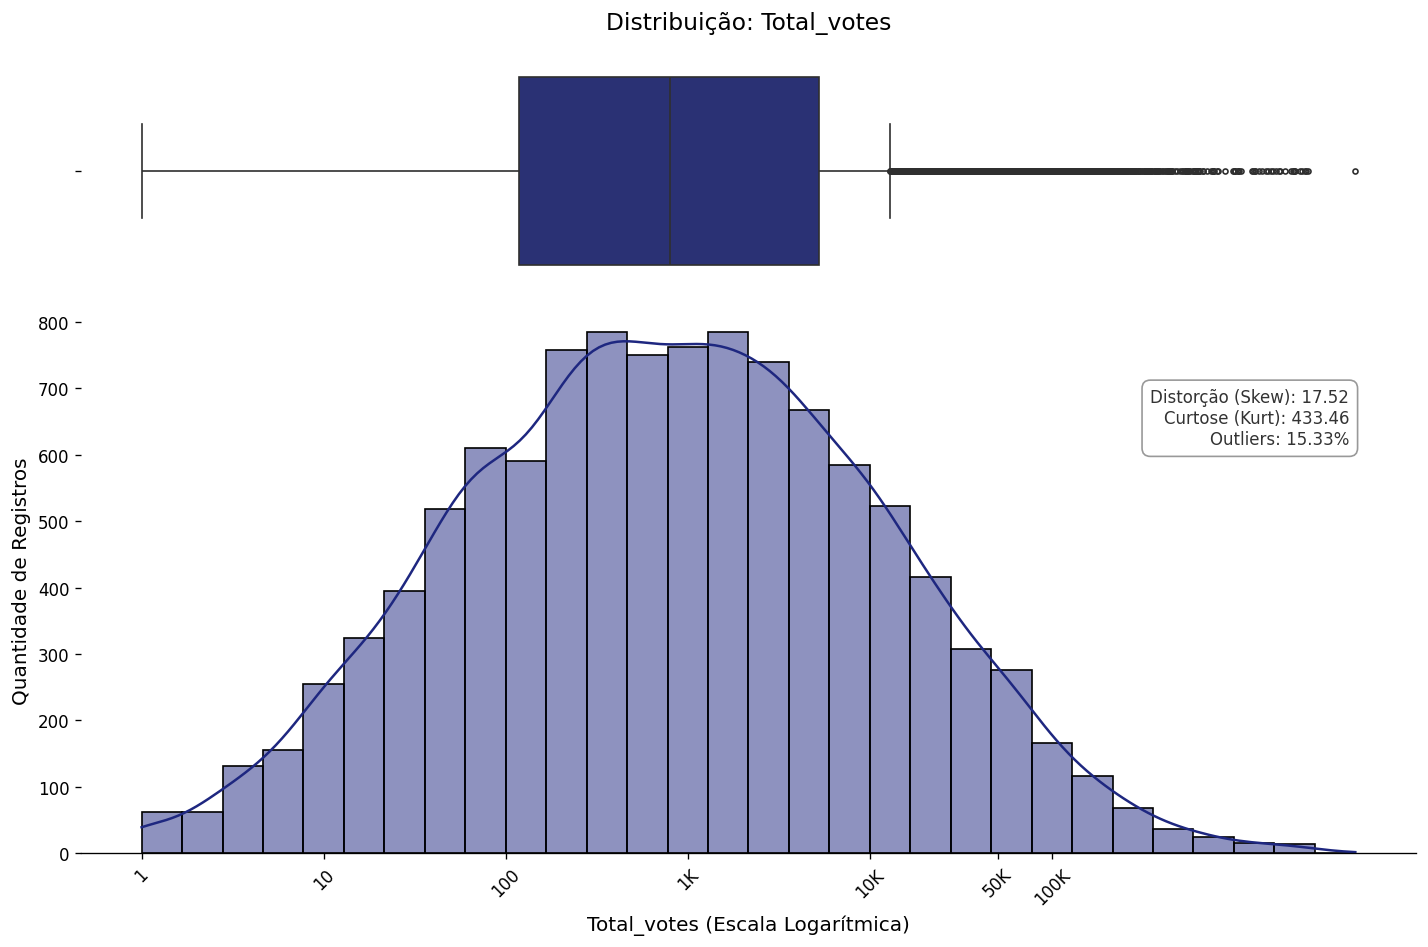

In [5]:
graf.grafico_distribuicao_numerica(
    df_plot=df_books, 
    coluna='total_votes', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='contagem'
)

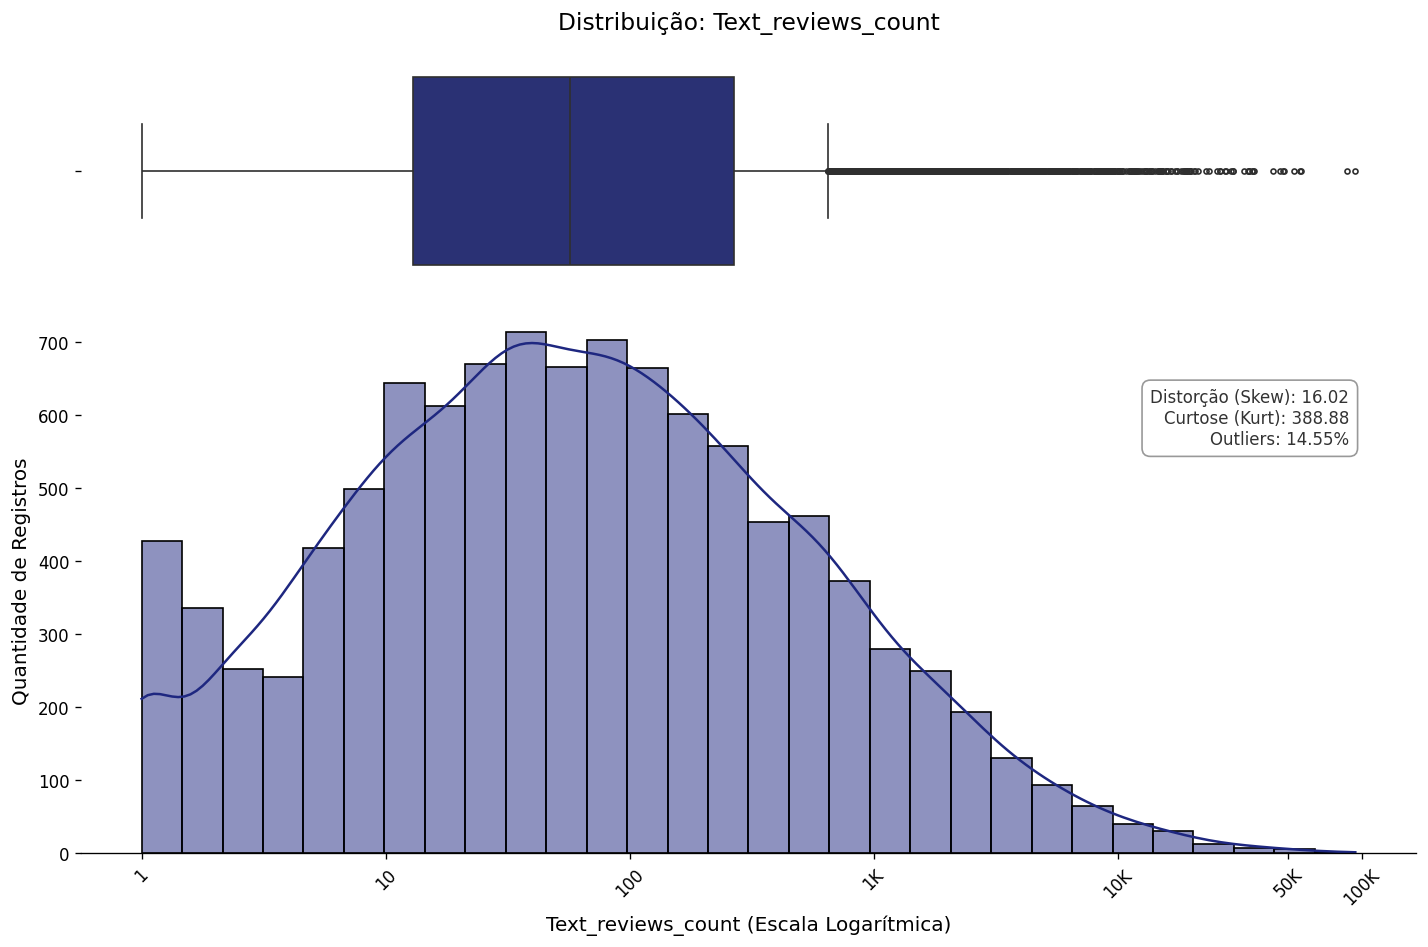

In [6]:
graf.grafico_distribuicao_numerica(
    df_plot=df_books, 
    coluna='text_reviews_count', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='contagem'
)

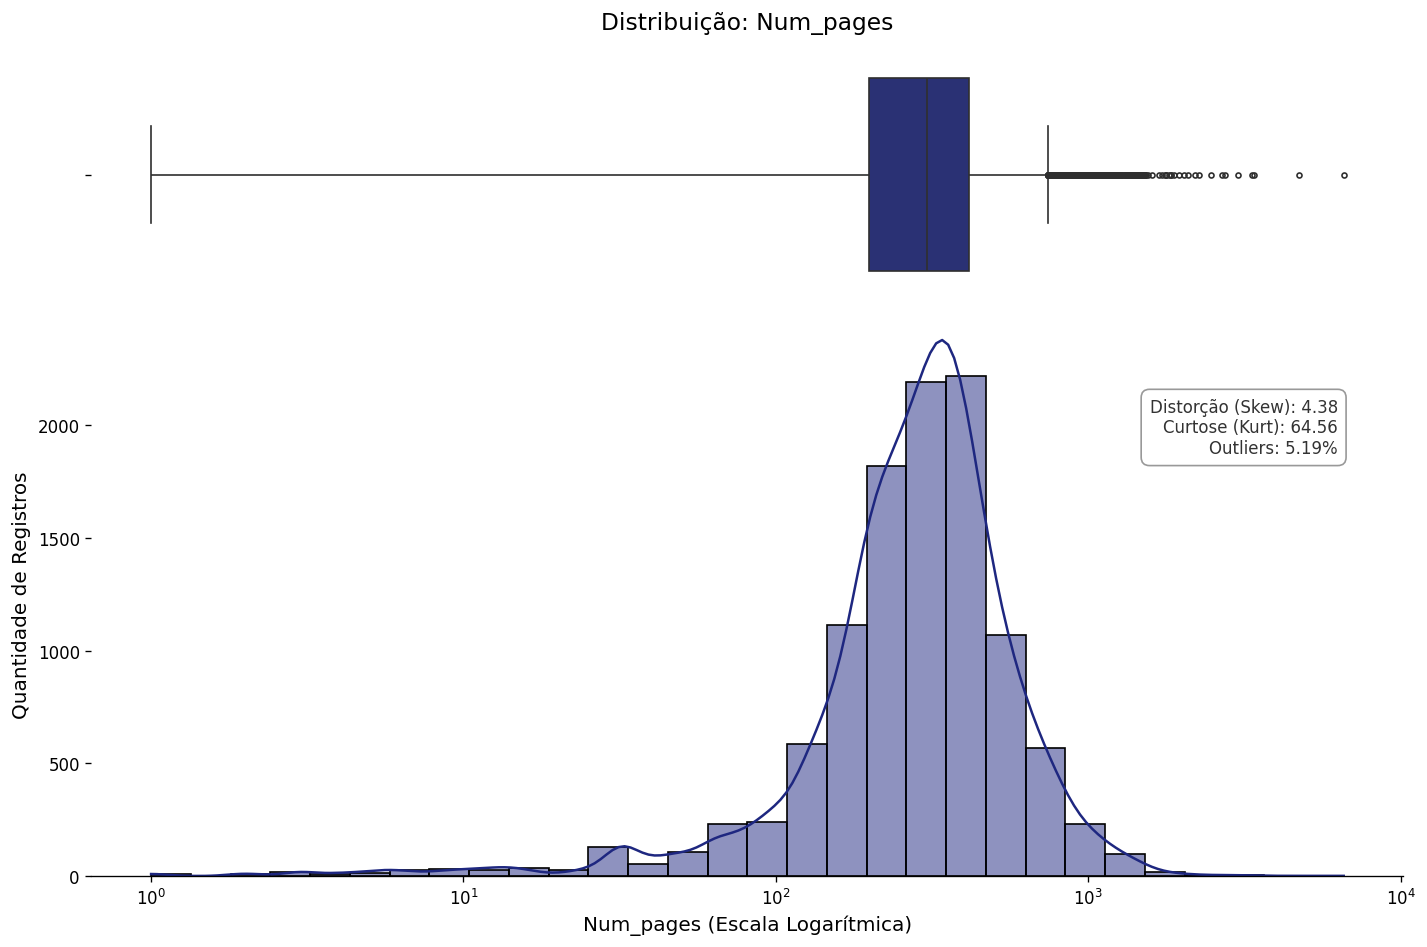

In [7]:
graf.grafico_distribuicao_numerica(
    df_plot=df_books, 
    coluna='num_pages', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True
)

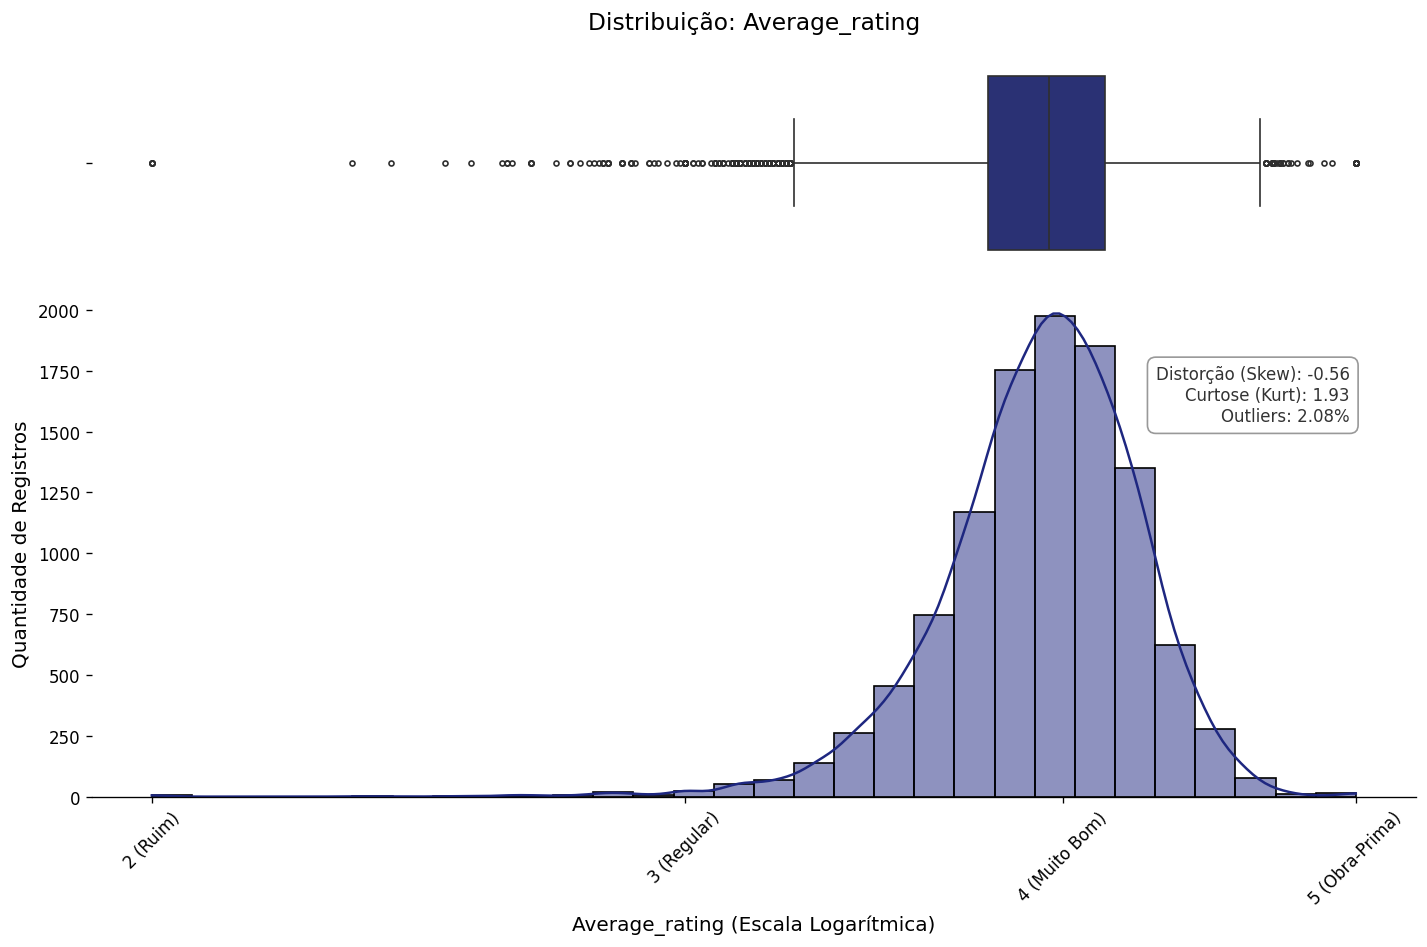

In [8]:
graf.grafico_distribuicao_numerica(
    df_plot=df_books, 
    coluna='average_rating', 
    relatorio_df=resumo_cols_numericas, 
    usar_log=True, 
    tipo_dado='nota_5'
)

### Colunas Categoricas

In [9]:
# Análisado Colunas Categorical Individualmente
resumo_cols_categoricas = mt.categorical_summary(df_books)
display(
    tb.estilizar_relatorio_categorias(
        resumo_cols_categoricas,
        caption="Relatorio colunas categoricas"
    )
)

,total_valid_rows,unique_categories,entropy_norm,top_values_count,top_values_pct_%
column,,,,,
isbn,10897,10897,1.000000,• 0439785960 (1)• 0439358078 (1)• 0439554896 (1)• 043965548X (1)• 0439682584 (1)• 0976540606 (1)• 0439827604 (1)• 0517226952 (1)• 0345453743 (1)• 1400052920 (1),• 0439785960 (0.0%)• 0439358078 (0.0%)• 0439554896 (0.0%)• 043965548X (0.0%)• 0439682584 (0.0%)• 0976540606 (0.0%)• 0439827604 (0.0%)• 0517226952 (0.0%)• 0345453743 (0.0%)• 1400052920 (0.0%)
popularity_tier,10897,4,0.999100,• Mainstream Hit (2894)• Nicho (2806)• Hidden Gem / Cult (2638)• Mass Appeal (2559),• Mainstream Hit (26.6%)• Nicho (25.8%)• Hidden Gem / Cult (24.2%)• Mass Appeal (23.5%)
title,10897,10142,0.995200,• The Iliad (9)• The Brothers Karamazov (9)• The Odyssey (8)• Anna Karenina (8)• A Midsummer Night's Dream (7)• 'Salem's Lot (7)• Gulliver's Travels (7)• The Picture of Dorian Gray (7)• Sense and Sensibility (6)• Jane Eyre (6),• The Iliad (0.1%)• The Brothers Karamazov (0.1%)• The Odyssey (0.1%)• Anna Karenina (0.1%)• A Midsummer Night's Dream (0.1%)• 'Salem's Lot (0.1%)• Gulliver's Travels (0.1%)• The Picture of Dorian Gray (0.1%)• Sense and Sensibility (0.1%)• Jane Eyre (0.1%)
author,10897,6491,0.954100,• Stephen King (40)• P.G. Wodehouse (40)• Rumiko Takahashi (38)• Orson Scott Card (35)• Agatha Christie (33)• Piers Anthony (30)• Mercedes Lackey (29)• Sandra Brown (29)• Dick Francis (28)• Margaret Weis/Tracy Hickman (23),• Stephen King (0.4%)• P.G. Wodehouse (0.4%)• Rumiko Takahashi (0.3%)• Orson Scott Card (0.3%)• Agatha Christie (0.3%)• Piers Anthony (0.3%)• Mercedes Lackey (0.3%)• Sandra Brown (0.3%)• Dick Francis (0.3%)• Margaret Weis/Tracy Hickman (0.2%)
producer_company,10897,2221,0.844500,• Vintage (318)• Penguin Books (261)• Penguin Classics (184)• Mariner Books (148)• Ballantine Books (143)• HarperCollins (112)• Harper Perennial (112)• Pocket Books (111)• Bantam (110)• VIZ Media LLC (88),• Vintage (2.9%)• Penguin Books (2.4%)• Penguin Classics (1.7%)• Mariner Books (1.4%)• Ballantine Books (1.3%)• HarperCollins (1.0%)• Harper Perennial (1.0%)• Pocket Books (1.0%)• Bantam (1.0%)• VIZ Media LLC (0.8%)
genres,10897,852,0.745200,"• Fiction (6801)• Classics (3305)• Nonfiction (3070)• Literature (2829)• Fantasy (2526)• Novels (2509)• Historical,Historical Fiction (1771)• Audiobook (1613)• History (1581)• Mystery (1566)","• Fiction (62.4%)• Classics (30.3%)• Nonfiction (28.2%)• Literature (26.0%)• Fantasy (23.2%)• Novels (23.0%)• Historical,Historical Fiction (16.3%)• Audiobook (14.8%)• History (14.5%)• Mystery (14.4%)"
original_language,10897,25,0.238000,• eng (8725)• en-US (1395)• en-GB (211)• spa (209)• fre (137)• ger (94)• jpn (45)• mul (19)• zho (14)• por (10),• eng (80.1%)• en-US (12.8%)• en-GB (1.9%)• spa (1.9%)• fre (1.3%)• ger (0.9%)• jpn (0.4%)• mul (0.2%)• zho (0.1%)• por (0.1%)


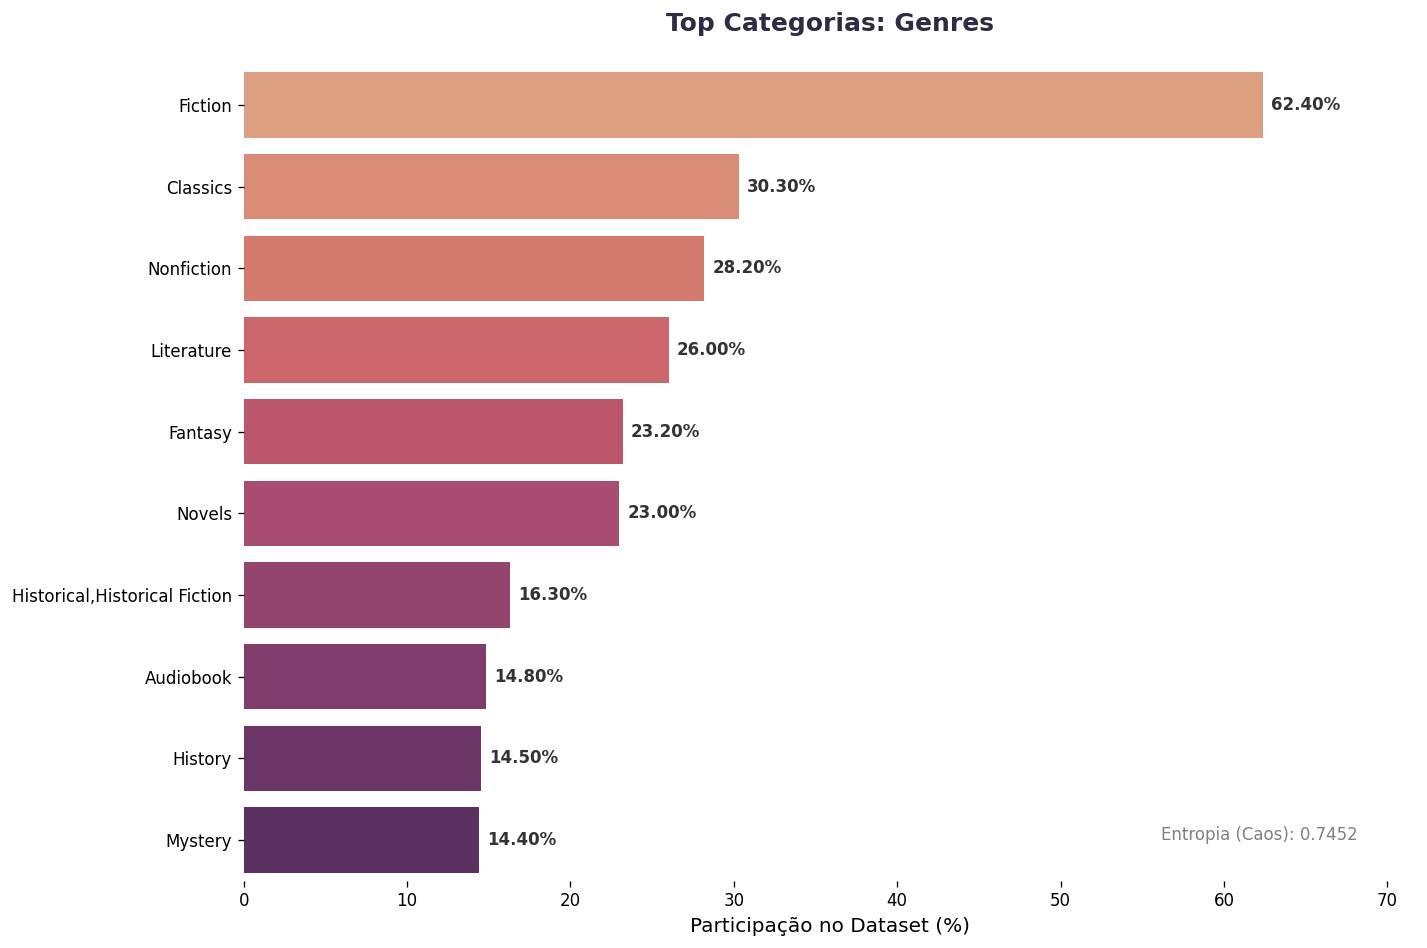

In [10]:
graf.grafico_top_categorias(df_books, 'genres', resumo_cols_categoricas)

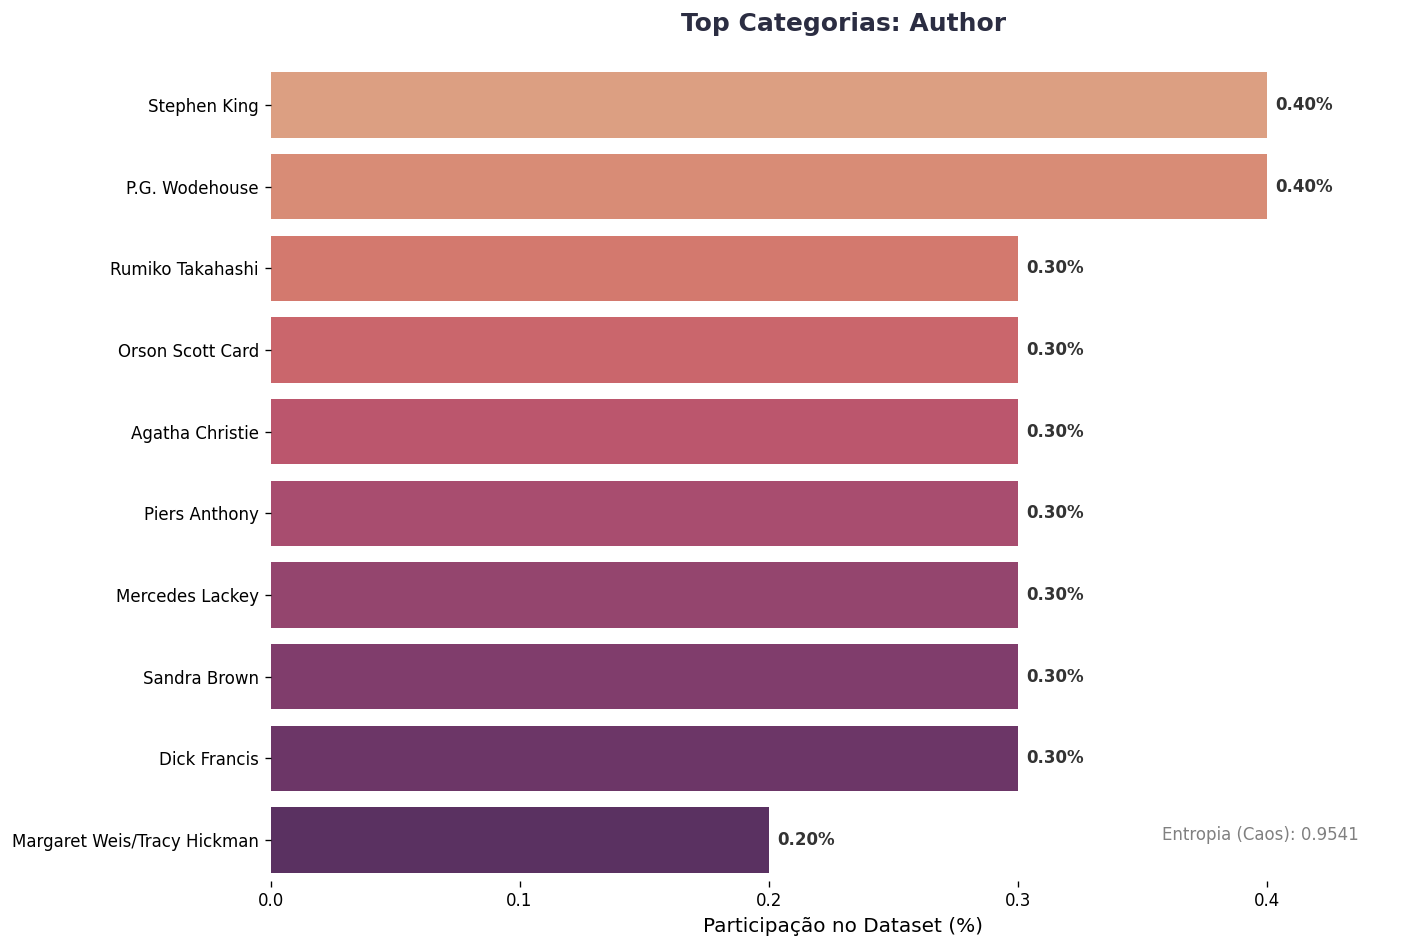

In [11]:
graf.grafico_top_categorias(df_books, 'author', resumo_cols_categoricas)

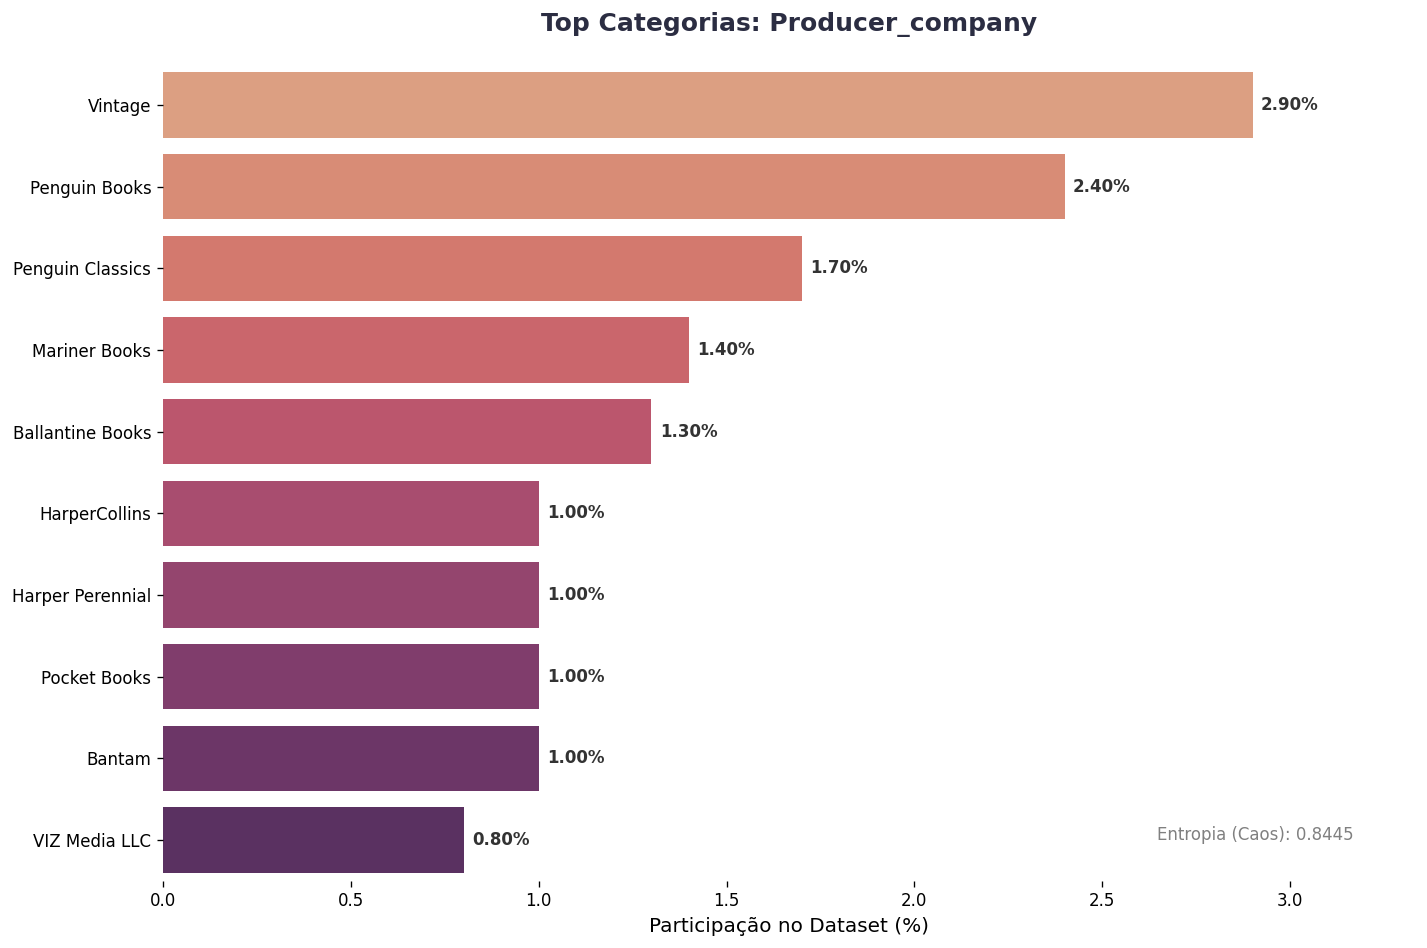

In [12]:
graf.grafico_top_categorias(df_books, 'producer_company', resumo_cols_categoricas)

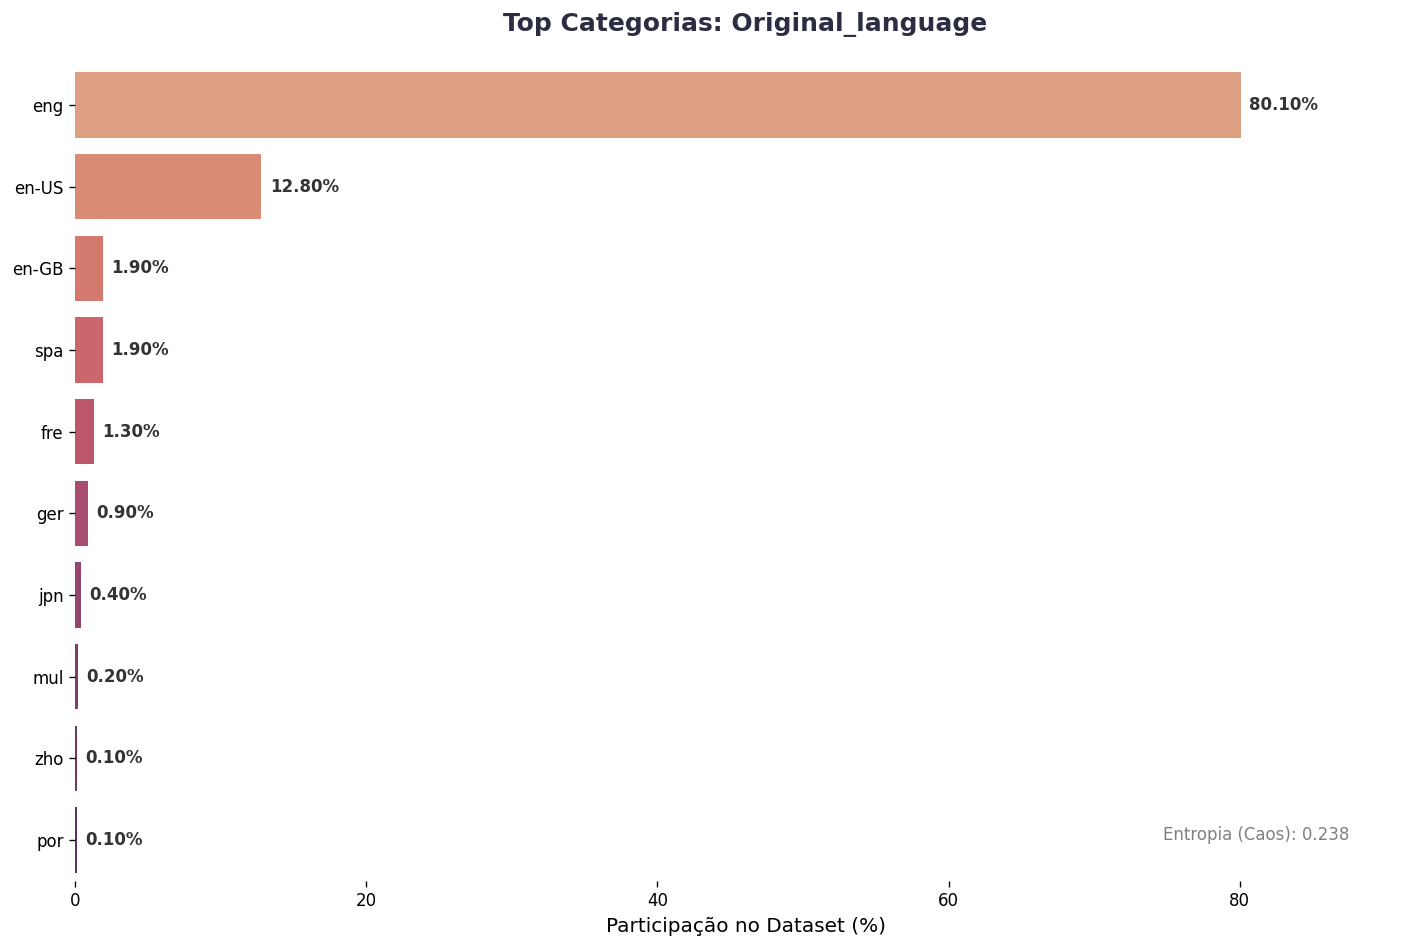

In [13]:
graf.grafico_top_categorias(df_books, 'original_language', resumo_cols_categoricas)

### Colunas de Tempo

In [14]:
relatorio_cols_date = mt.datetime_summary(df_books)

display(
    tb.estilizar_tabela(
        relatorio_cols_date,
        caption="Relatorio colunas date"
    )
)

,min,max,range_years,unique_dates,most_frequent_year,most_frequent_month
column,,,,,,
release_date,1900-01-01,2020-03-31,120,3618,2006,9


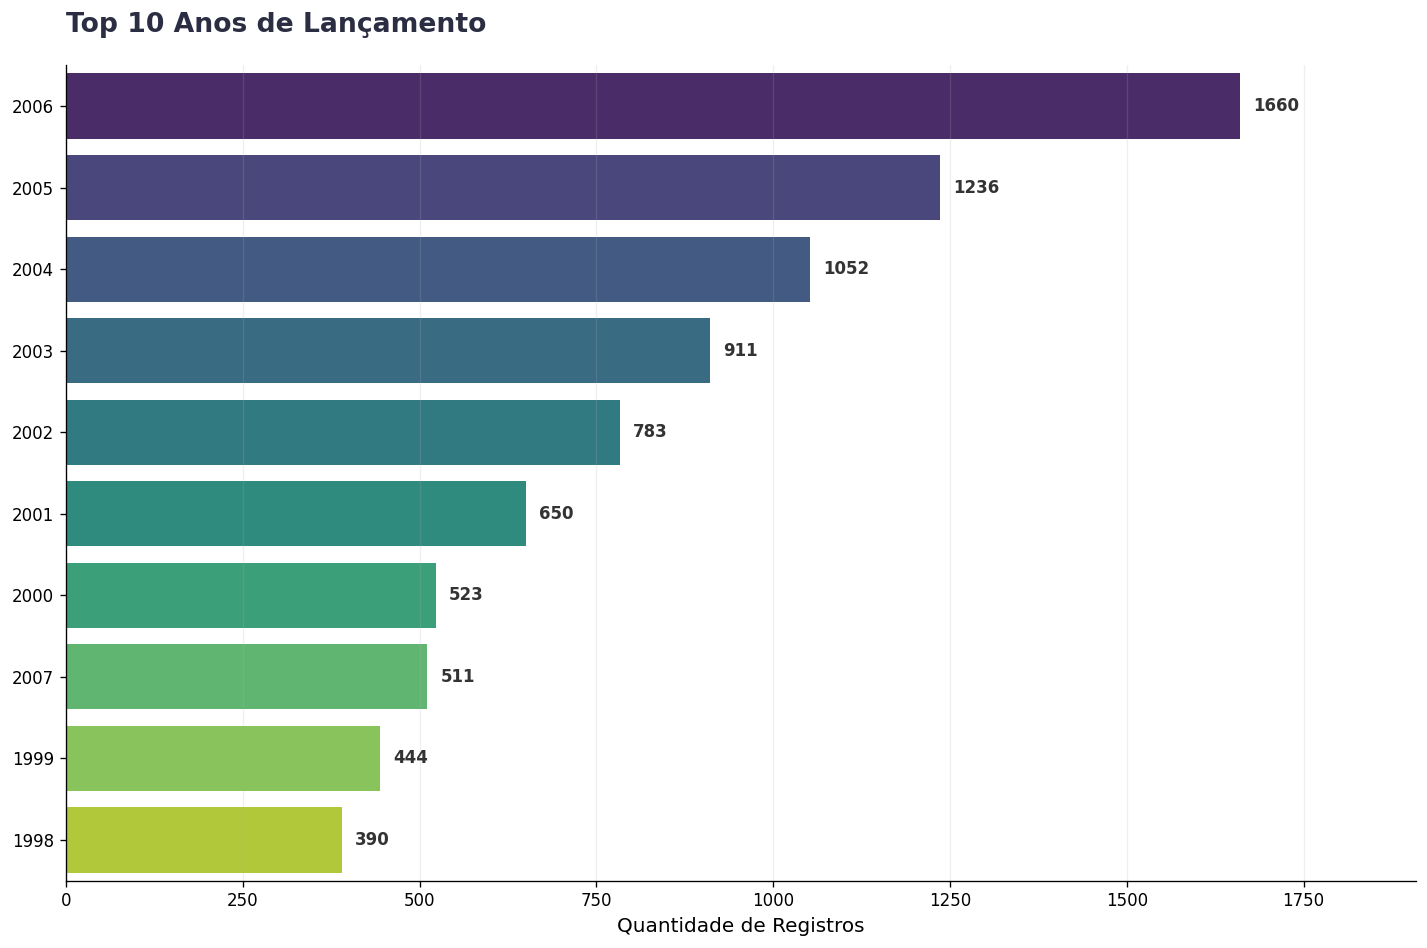

In [15]:
graf.graficos_top_release(df_books, 'release_date', data='year')

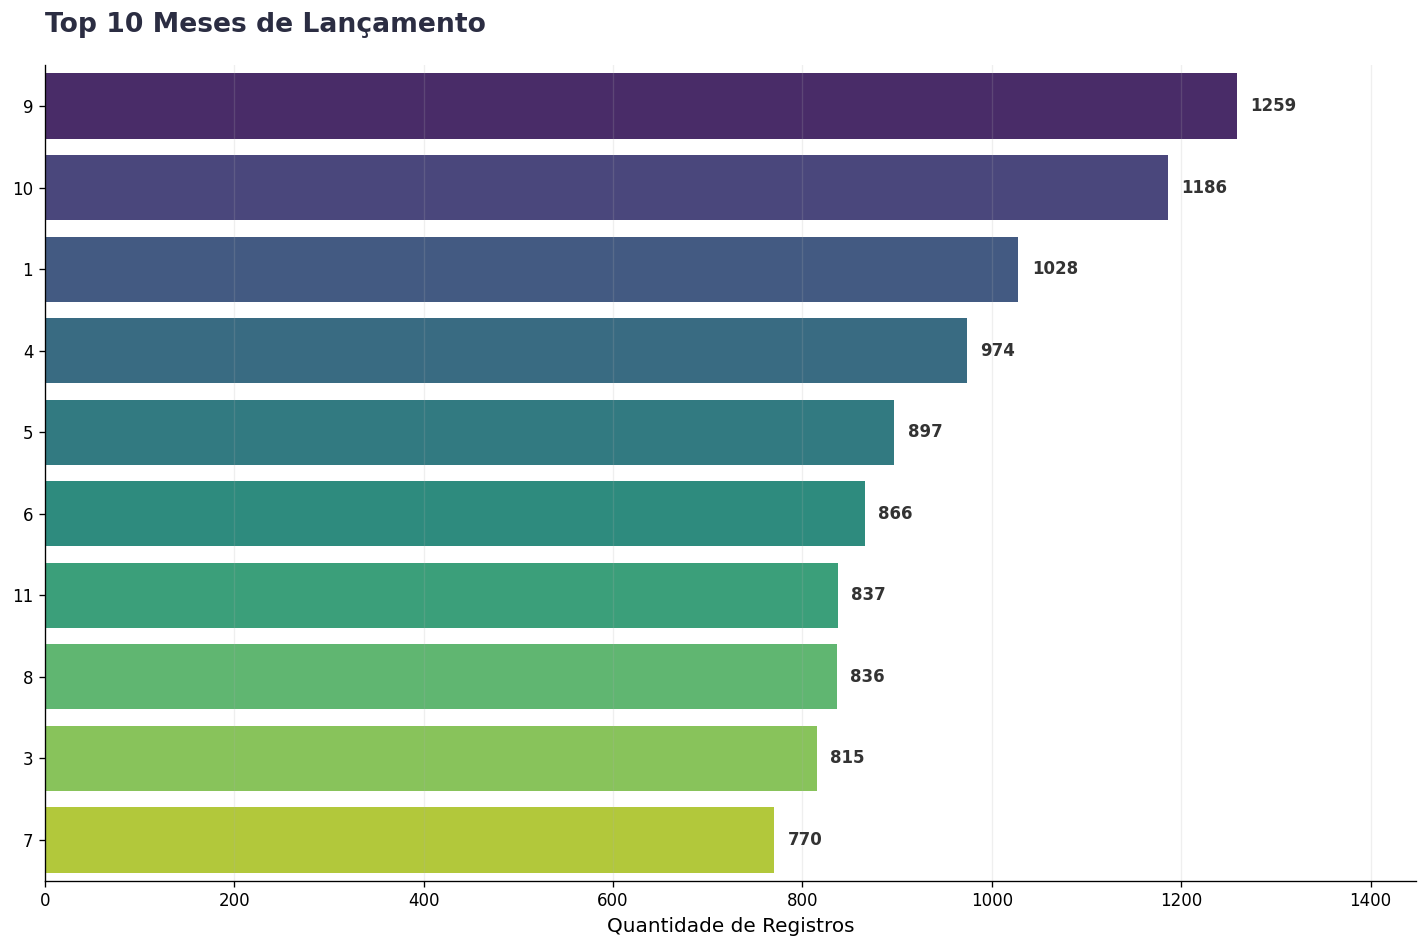

In [16]:
graf.graficos_top_release(df_books, 'release_date', data='month')

# Conclusões da Análise Univariada 

## 1. Variáveis Numéricas

* **`ratings_count` e `text_reviews_count` (Engajamento):** Assimetria extrema (Cauda Longa). A maioria dos livros tem poucos votos (mediana de 784), enquanto uma minoria de best-sellers concentra milhões de avaliações. Escala logarítmica indispensável para visualização.
* **`num_pages` (Tamanho):** Concentração no padrão de **300 a 338 páginas**. Presença de volumes extremos (até 6.576 páginas) gerando 5.08% de outliers (possíveis boxes/coleções).
* **`average_rating` (Notas):** Distribuição Normal perfeitamente equilibrada, concentrada entre **3.5 e 4.2** (média 3.94). O público leitor é generoso; notas menores que 2.0 ou perfeitas (5.0) são raras.

## 2. Variáveis Categorizadas

* **`language_code` (Idioma):** Baixíssima entropia (0.23). Domínio absoluto do inglês (> 94.9%). O português representa apenas 0.1%. Será útil para segmentar o Dashboard por mercado.
* **`genres` (Gêneros):** Alta entropia (0.74). Mercado bem distribuído. *Fiction* (62.5%) e *Classics* (30.3%) lideram, mas Fantasia, Mistério e Ficção Histórica têm fatias relevantes.
* **`title` e `Author`:** Alta fragmentação (entropia > 0.95). Stephen King e P.G. Wodehouse lideram com apenas 0.4% do catálogo cada.

## 3. Variáveis Temporais
* **Volume por Mês:** O **mês 9 (Setembro)** é o líder em registros, mas o catálogo é homogêneo ao longo do ano (diferença de apenas **~500 livros** entre o maior e o menor mês).
* **Pico Histórico:** O ano com maior volume de publicações foi **2006**.
* **Granularidade:** O acervo é altamente pulverizado, contendo **3.632 datas únicas**.
* **Filtro Inicial (1900):** O limite inferior começa em **1900**. Como o dataset trata de registros comerciais (`isbn`), datas pós-1900 incluem **republicações e novas edições** de livros e clássicos muito mais antigos.

## 4. Qualidade dos Dados (Auditoria)

* **`isbn`:** Preservado como identificador padrão para futuros cruzamentos externos.
* **Duplicados:** A coluna `title` possui reedições e formatos diferentes (Paperback/Hardcover) do mesmo livro, gerando repetições legítimas de clássicos.
